# House Price Prediction — 3. Modeling

We train and compare three regression models:
1. **Linear Regression** — simple baseline
2. **Random Forest Regressor** — bagged tree ensemble
3. **XGBoost (Gradient Boosting)** — boosted tree ensemble, usually strongest on tabular data

All models predict `log(price)`. We evaluate them on the **original price scale** (after reversing the log transform) since that's what's actually meaningful to a user.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
price_test = pd.read_csv('../data/processed/price_test.csv').squeeze()

print(X_train.shape, X_test.shape)

(92889, 20) (23223, 20)


## Evaluation helper

We define one function so all models are scored identically, on the de-logged price scale.

In [2]:
results = {}

def evaluate_model(name, y_pred_log, y_true_price):
    y_pred_price = np.expm1(y_pred_log)
    y_pred_price = np.clip(y_pred_price, 0, None)  # guard against tiny negative artifacts
    mae = mean_absolute_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    r2 = r2_score(y_true_price, y_pred_price)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'predictions': y_pred_price}
    print(f'{name}:  MAE = {mae:,.0f} PKR   RMSE = {rmse:,.0f} PKR   R2 = {r2:.4f}')
    return y_pred_price

## 1. Linear Regression (baseline, uses scaled features)

In [3]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred_log = lr.predict(X_test_scaled)
lr_pred_price = evaluate_model('Linear Regression', lr_pred_log, price_test)

Linear Regression:  MAE = 9,349,664 PKR   RMSE = 25,670,662 PKR   R2 = -0.0899


## 2. Random Forest Regressor (uses unscaled features — trees don't need scaling)

In [4]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=18, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
rf_pred_log = rf.predict(X_test)
rf_pred_price = evaluate_model('Random Forest', rf_pred_log, price_test)

Random Forest:  MAE = 3,253,167 PKR   RMSE = 7,330,911 PKR   R2 = 0.9111


## 3. XGBoost Regressor

In [5]:
xgb = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred_log = xgb.predict(X_test)
xgb_pred_price = evaluate_model('XGBoost', xgb_pred_log, price_test)

XGBoost:  MAE = 3,563,942 PKR   RMSE = 7,600,896 PKR   R2 = 0.9044


## Model Comparison

In [6]:
comparison = pd.DataFrame({k: {m: v[m] for m in ['MAE','RMSE','R2']} for k, v in results.items()}).T
comparison = comparison.sort_values('RMSE')
comparison

,MAE,RMSE,R2
Random Forest,3.253167e+06,7.330911e+06,0.911116
XGBoost,3.563942e+06,7.600896e+06,0.904448
Linear Regression,9.349664e+06,2.567066e+07,-0.089893


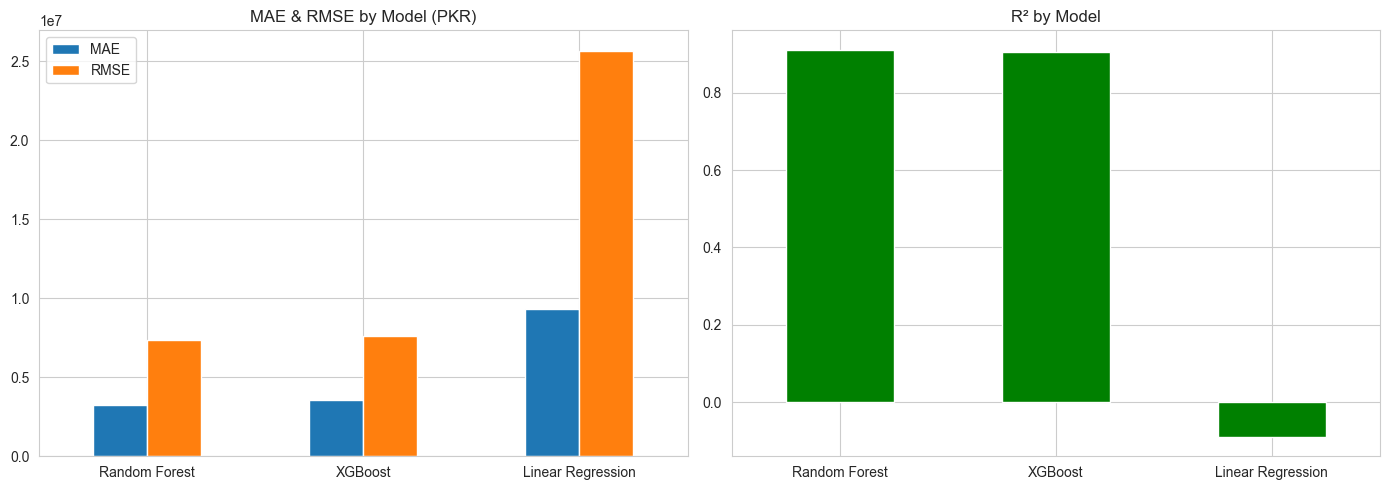

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
comparison[['MAE','RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('MAE & RMSE by Model (PKR)')
axes[0].tick_params(axis='x', rotation=0)

comparison['R2'].plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('R² by Model')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Feature Importance (XGBoost)

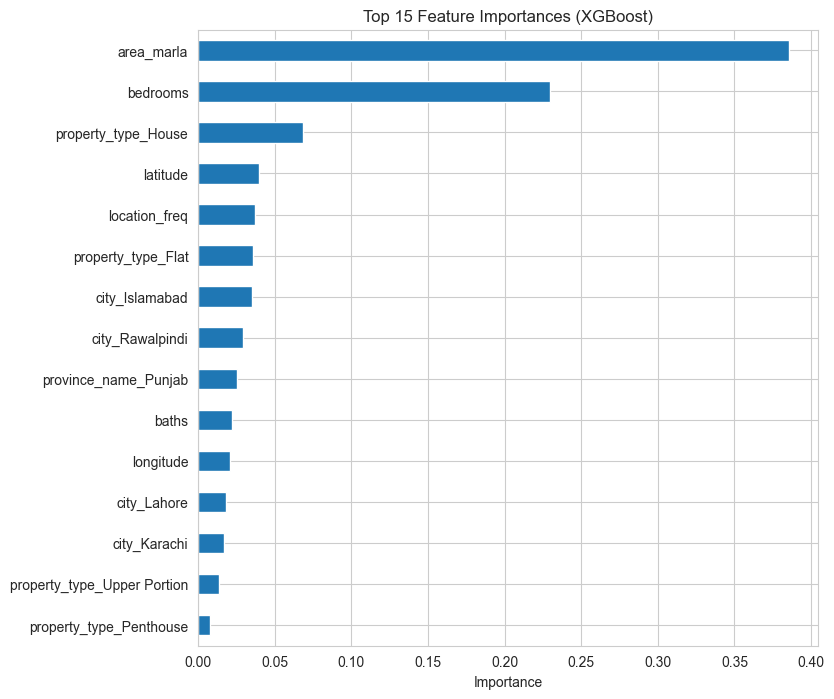

In [8]:
importance = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,8))
importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.show()

## Save the best model

In [9]:
best_model_name = comparison['RMSE'].idxmin()
print('Best model by RMSE:', best_model_name)

models = {'Linear Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}
best_model = models[best_model_name]

joblib.dump(best_model, '../data/processed/best_model.pkl')
joblib.dump(X_train.columns.tolist(), '../data/processed/feature_columns.pkl')
joblib.dump(best_model_name, '../data/processed/best_model_name.pkl')

# Save all predictions for the visualization notebook
preds_df = pd.DataFrame({
    'actual_price': price_test.values,
    'linear_regression_pred': lr_pred_price,
    'random_forest_pred': rf_pred_price,
    'xgboost_pred': xgb_pred_price,
})
preds_df.to_csv('../data/processed/predictions.csv', index=False)
comparison.to_csv('../data/processed/model_comparison.csv')
print('Saved best model and predictions.')

Best model by RMSE: Random Forest
Saved best model and predictions.


## Summary

All three models were trained on `log(price)` and evaluated back on the original PKR scale using MAE, RMSE, and R². The comparison table and feature importance plot above show which model performed best and which features matter most for predicting Pakistani house prices (typically area, location frequency, and city dominate).

Next: **04_predictions.ipynb** — focused visual comparison of predicted vs actual prices, plus error analysis.